In [7]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('/home/mahaputra777/pt_skp/ContainerSmartStay/agoda_css_20260518_143728.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   reviewer_name       59 non-null     object 
 1   user_country        59 non-null     object 
 2   room_type           59 non-null     object 
 3   stay_duration_days  59 non-null     int64  
 4   rating              59 non-null     float64
 5   review_text         59 non-null     object 
 6   review_date         47 non-null     object 
dtypes: float64(1), int64(1), object(5)
memory usage: 3.4+ KB


In [10]:
df.head(10)

,reviewer_name,user_country,room_type,stay_duration_days,rating,review_text,review_date
0,Krisma,Indonesia,Standard Room,1,10.0,"The place is clean and nice, the staff is frie...","Responded July 02, 2025"
1,Putrilia,Indonesia,Superior Room,1,10.0,"Nice concept of staying, very clean, not so no...","January 31, 2026"
2,Sagung,Indonesia,Superior Room,2,10.0,Stayed for 2 days here on New Year's Eve. Ever...,NaN
3,Indrayani,Indonesia,Superior Room,1,10.0,"A unique, clean, and comfortable hotel where w...",NaN
4,Budi,Indonesia,Superior Room,2,9.2,"The staff service is very good, the cleanlines...",NaN
5,Evi,Indonesia,Standard Room,1,10.0,"This place is really close to Bali Farm House,...",NaN
6,Jeni,Indonesia,Standard Room,2,10.0,"Comfortable place, all staff are friendly and ...",NaN
7,Michael,Indonesia,Standard Room,2,9.6,"This place is nice, but maybe it just needs to...",NaN
8,Putu,Indonesia,Standard Room,2,9.2,"Initially, I was scrolling through Agoda looki...",NaN
9,Adi,Indonesia,Superior Room,1,6.8,"The interior has quite a few issues, such as a...",NaN


In [11]:
# 1. Bersihkan awalan "Diulas pada " di kolom review_date
# Kita gunakan regex=False agar proses lebih cepat karena teksnya pasti
df['review_date'] = df['review_date'].str.replace('Diulas pada ', '', regex=False)

# 2. Ambil Bulan dan Tahun dari kolom 'stay_duration_days' untuk mengisi NaN
# Pola regex: cari kata setelah 'pada ' sampai akhir string
# Contoh: "Menginap 1 malam pada Mei 2024" -> akan diambil "Mei 2024"
extracted_dates = df['stay_duration_days'].astype(str).str.extract(r'pada\s+(.*)', expand=False)

# 3. Isi data NaN di 'review_date' dengan hasil ekstraksi tersebut
df['review_date'] = df['review_date'].fillna(extracted_dates)

# 4. TERJEMAHKAN Bulan Indonesia ke Inggris
# Ini langkah krusial agar pd.to_datetime tidak error membaca "Juli", "Mei", "Agustus", dll.
map_bulan = {
    'Januari': 'January',
    'Februari': 'February',
    'Maret': 'March',
    'April': 'April',
    'Mei': 'May',
    'Juni': 'June',
    'Juli': 'July',
    'Agustus': 'August',
    'September': 'September',
    'Oktober': 'October',
    'November': 'November',
    'Desember': 'December'
}

# Lakukan replace string
for idn, eng in map_bulan.items():
    # Pastikan data string sebelum direplace
    df['review_date'] = df['review_date'].astype(str).str.replace(idn, eng, regex=False)

# 5. Konversi ke Datetime
# errors='coerce' akan mengubah data yang tetap error menjadi NaT (Not a Time) daripada menghentikan program
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# Cek hasil
print("Tipe data:", df['review_date'].dtypes)
print("\nContoh data hasil konversi:")
print(df['review_date'].head())

# Cek apakah masih ada yang error/NaT
print(f"\nJumlah data yang gagal diparsing (NaT): {df['review_date'].isna().sum()}")

Tipe data: datetime64[ns]

Contoh data hasil konversi:
0          NaT
1   2026-01-31
2          NaT
3          NaT
4          NaT
Name: review_date, dtype: datetime64[ns]

Jumlah data yang gagal diparsing (NaT): 13


/tmp/ipykernel_10415/3763595871.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')


In [12]:
df.head() 

,reviewer_name,user_country,room_type,stay_duration_days,rating,review_text,review_date
0,Krisma,Indonesia,Standard Room,1,10.0,"The place is clean and nice, the staff is frie...",NaT
1,Putrilia,Indonesia,Superior Room,1,10.0,"Nice concept of staying, very clean, not so no...",2026-01-31
2,Sagung,Indonesia,Superior Room,2,10.0,Stayed for 2 days here on New Year's Eve. Ever...,NaT
3,Indrayani,Indonesia,Superior Room,1,10.0,"A unique, clean, and comfortable hotel where w...",NaT
4,Budi,Indonesia,Superior Room,2,9.2,"The staff service is very good, the cleanlines...",NaT


In [13]:
def plot_barplot(data, x_col, y_col, title="", format_number="", x_label="", y_label="", colour_bar_set="3"):
    plt.figure(figsize=(10, max(6, len(data) * 0.4))) # Tinggi otomatis menyesuaikan banyaknya negara

    # --- 1. DETEKSI OTOMATIS: VERTIKAL ATAU HORIZONTAL? ---
    # Jika Y-nya angka, berarti Vertikal. Jika Y-nya teks, berarti Horizontal.
    if pd.api.types.is_numeric_dtype(data[y_col]):
        orientation = 'vertical'
        color_basis = data[y_col] # Warna ikut tinggi Y
    else:
        orientation = 'horizontal'
        color_basis = data[x_col] # Warna ikut panjang X (Jumlah)

    # --- 2. LOGIKA WARNA ---
    if colour_bar_set == "1": # Tinggi=Hijau
        norm = plt.Normalize(color_basis.min(), color_basis.max())
        sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
        colors = [sm.to_rgba(val) for val in color_basis]
    elif colour_bar_set == "2": # Tinggi=Merah
        norm = plt.Normalize(color_basis.min(), color_basis.max())
        sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
        colors = [sm.to_rgba(val) for val in color_basis]
    else: # Mode 3 (Default Biru - Aman untuk Kategori)
        colors = ["#4c72b0"] * len(data)
        sm = None

    # --- 3. MEMBUAT PLOT ---
    barplot = sns.barplot(
        x=x_col, 
        y=y_col,
        data=data,
        palette=colors,
        hue=y_col if orientation == 'horizontal' else x_col, # Fix warning seaborn baru
        legend=False
    )

    # --- 4. MEMBERI LABEL ANGKA (SMART POSITIONING) ---
    for bar in barplot.patches:
        # Ambil dimensi batang
        width = bar.get_width()
        height = bar.get_height()
        
        # Tentukan nilai yang akan ditulis
        value = width if orientation == 'horizontal' else height
        if np.isnan(value): continue

        # Format label
        if isinstance(value, float):
            label_text = f"{format_number}{value:.2f}"
            if value.is_integer(): label_text = f"{format_number}{int(value)}"
        else:
            label_text = f"{format_number}{int(value)}"

        # Tentukan posisi teks
        if orientation == 'horizontal':
            # Jika horizontal, teks ditaruh di sebelah kanan ujung batang
            text_x = width + (data[x_col].max() * 0.01) # Beri sedikit jarak
            text_y = bar.get_y() + height / 2
            ha_align = 'left'
            color_text = 'black' # Teks hitam biar terbaca di background putih
        else:
            # Jika vertikal, teks ditaruh di tengah/atas batang
            text_x = bar.get_x() + width / 2
            text_y = bar.get_y() + height / 2
            ha_align = 'center'
            color_text = 'white'

        plt.text(
            text_x, 
            text_y, 
            label_text, 
            va='center', 
            ha=ha_align, 
            fontsize=10, 
            color=color_text, 
            weight='bold'
        )

    # Kosmetik
    plt.title(title, loc="center", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel(x_label if x_label else x_col, fontsize=12)
    plt.ylabel(y_label if y_label else y_col, fontsize=12)
    
    if orientation == 'vertical':
        plt.grid(axis='y', linestyle='--', alpha=0.3)
    else:
        plt.grid(axis='x', linestyle='--', alpha=0.3) # Grid X untuk horizontal

    plt.tight_layout()
    plt.show()

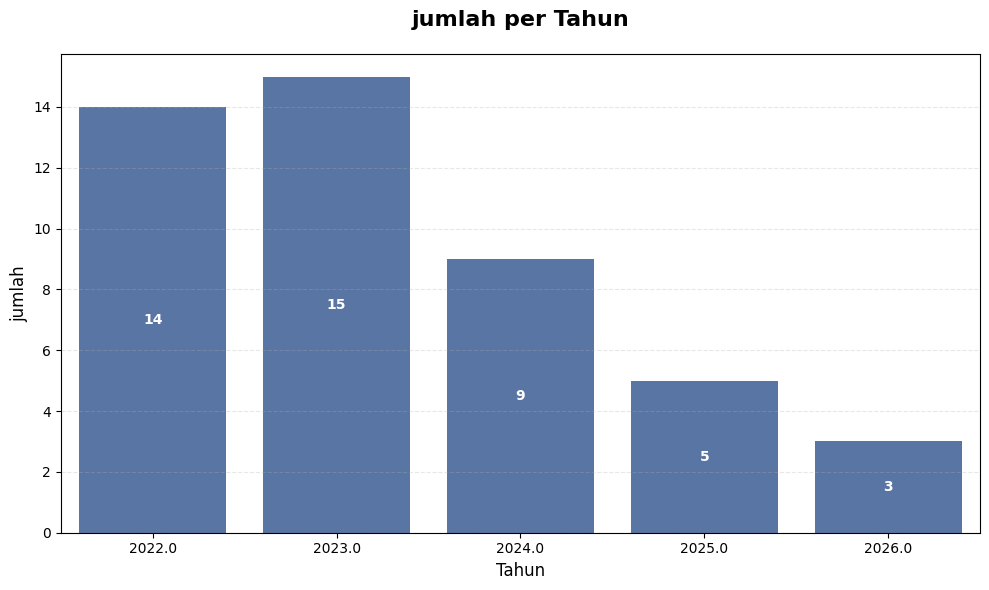

,tahun,jumlah
0,2022.0,14
1,2023.0,15
2,2024.0,9
3,2025.0,5
4,2026.0,3


In [14]:
# --- 1. DATA PREPARATION ---

# Pastikan kolom tanggal bertipe datetime
# Jika format tanggalmu beda (misal: "12 Dec 2023"), pandas biasanya otomatis mengenali
df['review_date'] = pd.to_datetime(df['review_date'])

# Ekstrak tahun ke kolom baru
df['year'] = df['review_date'].dt.year

# Hitung jumlah review per tahun dan URUTKAN BERDASARKAN TAHUN (sort_index)
# Kita pakai sort_index() agar tahunnya urut (2020, 2021, 2022...), bukan acak.
year_counts = df['year'].value_counts().sort_index()

# Konversi ke DataFrame agar mudah di-plot seaborn
year_df = year_counts.reset_index()
year_df.columns = ['tahun', 'jumlah']

# --- 2. VISUALISASI (Best Practice) ---

plot_barplot(
    data=year_df, 
    x_col="tahun", 
    y_col="jumlah", 
    title="jumlah per Tahun", 
    x_label="Tahun",
    y_label="jumlah",
    colour_bar_set="3" # Gunakan 3 (Biru) untuk data tahunan agar netral
)

year_df

In [15]:
df

,reviewer_name,user_country,room_type,stay_duration_days,rating,review_text,review_date,year
0,Krisma,Indonesia,Standard Room,1,10.0,"The place is clean and nice, the staff is frie...",NaT,NaN
1,Putrilia,Indonesia,Superior Room,1,10.0,"Nice concept of staying, very clean, not so no...",2026-01-31,2026.0
2,Sagung,Indonesia,Superior Room,2,10.0,Stayed for 2 days here on New Year's Eve. Ever...,NaT,NaN
3,Indrayani,Indonesia,Superior Room,1,10.0,"A unique, clean, and comfortable hotel where w...",NaT,NaN
4,Budi,Indonesia,Superior Room,2,9.2,"The staff service is very good, the cleanlines...",NaT,NaN
5,Evi,Indonesia,Standard Room,1,10.0,"This place is really close to Bali Farm House,...",NaT,NaN
6,Jeni,Indonesia,Standard Room,2,10.0,"Comfortable place, all staff are friendly and ...",NaT,NaN
7,Michael,Indonesia,Standard Room,2,9.6,"This place is nice, but maybe it just needs to...",NaT,NaN
8,Putu,Indonesia,Standard Room,2,9.2,"Initially, I was scrolling through Agoda looki...",NaT,NaN
9,Adi,Indonesia,Superior Room,1,6.8,"The interior has quite a few issues, such as a...",NaT,NaN


In [16]:
# 1. Ekstrak hanya angkanya saja dari teks "Menginap 1 malam pada..."
# Regex r'(\d+)' akan mengambil digit pertama yang ditemukan
df['stay_duration_days'] = df['stay_duration_days'].astype(str).str.extract(r'(\d+)', expand=False)

# 2. Ubah menjadi tipe data Integer
# Kita gunakan pd.to_numeric dengan errors='coerce' untuk keamanan
df['stay_duration_days'] = pd.to_numeric(df['stay_duration_days'], errors='coerce')

# 3. Handling NaN & Konversi ke int
# Jika ada data kosong/gagal (misal "Menginap semalam"), kita bisa isi dengan nilai default (misal 1)
# lalu diubah ke integer
df['stay_duration_days'] = df['stay_duration_days'].fillna(1).astype(int)

# Cek hasil
print(df['stay_duration_days'].head())
print(df['stay_duration_days'].dtypes)

0    1
1    1
2    2
3    1
4    2
Name: stay_duration_days, dtype: int64
int64


Jumlah data rating yang valid: 59
Contoh data rating: 0    10.0
1    10.0
2    10.0
3    10.0
4     9.2
Name: rating, dtype: float64

Data yang akan di-plot:
     year    rating
0  2022.0  8.542857
1  2023.0  9.253333
2  2024.0  9.333333
3  2025.0  9.360000
4  2026.0  8.266667


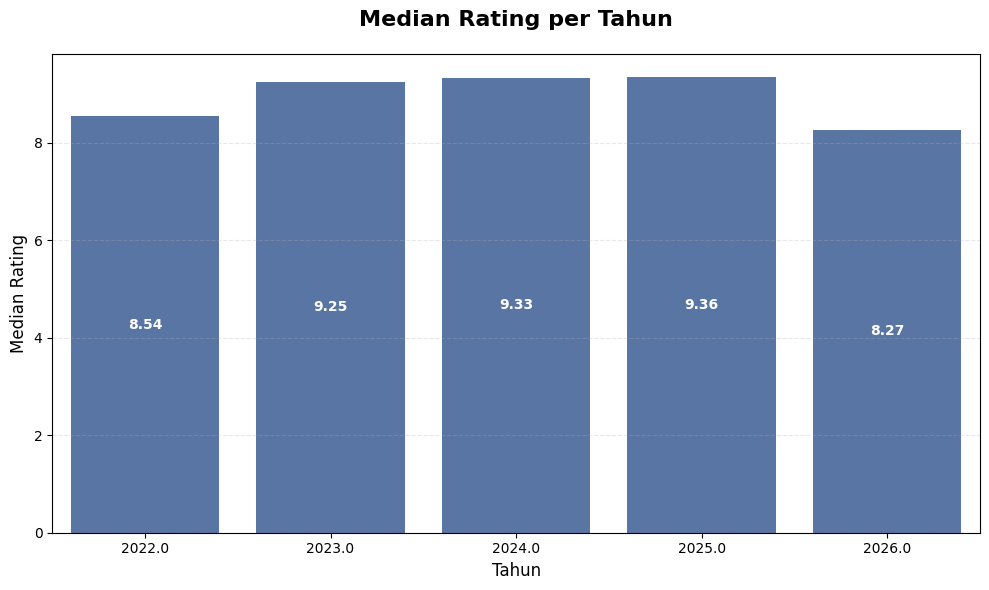

In [17]:
import pandas as pd

# 1. Ganti Koma menjadi Titik (PENTING)
# Kita ubah dulu ke string, ganti koma, baru konversi ke numerik
df['rating'] = df['rating'].astype(str).str.replace(',', '.', regex=False)

# 2. Bersihkan karakter non-angka (jika ada teks seperti '/5')
# Kita ambil hanya bagian angkanya saja
df['rating'] = df['rating'].str.extract(r'(\d+\.?\d*)', expand=False)

# 3. Konversi ke Float
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# 4. Pastikan kolom 'year' terbentuk dengan benar dari review_date
df['year'] = df['review_date'].dt.year

# --- CEK DATA (DEBUGGING) ---
print("Jumlah data rating yang valid:", df['rating'].notna().sum())
print("Contoh data rating:", df['rating'].head())

# Buat dataset untuk plot
plot_data = df.reset_index().groupby('year')['rating'].mean().reset_index(name='rating')

# Cek isi data yang mau di-plot
print("\nData yang akan di-plot:")
print(plot_data)

# --- PLOT ULANG ---
# Hanya plot jika datanya ada
if not plot_data.empty and plot_data['rating'].count() > 0:
    plot_barplot(
        data=plot_data, 
        x_col="year", 
        y_col="rating", 
        title="Median Rating per Tahun", 
        x_label="Tahun",
        y_label="Median Rating",
        colour_bar_set="3"
    )
else:
    print("Data kosong! Cek kembali format kolom 'rating' Anda.")

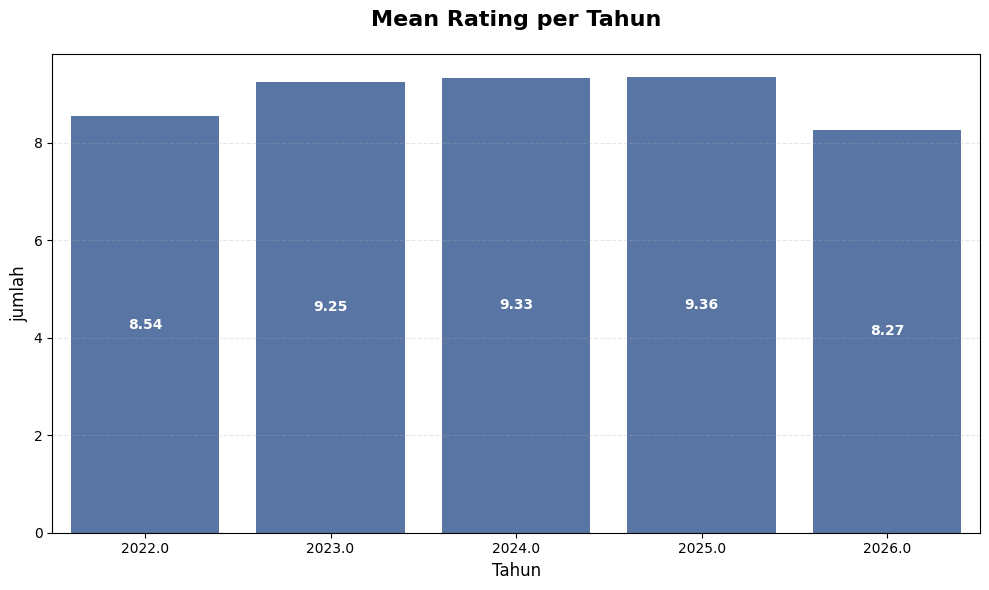

In [18]:

plot_barplot(
    data=df.reset_index().groupby('year').rating.mean().reset_index(name='rating'), 
    x_col="year", 
    y_col="rating", 
    title="Mean Rating per Tahun", 
    x_label="Tahun",
    y_label="jumlah",
    colour_bar_set="3" # Gunakan 3 (Biru) untuk data tahunan agar netral
)

## 2. Text Mining

In [19]:
# Pastikan nama kolom tahun sesuai (misal 'Year' atau 'year')
# zip menggabungkan dua kolom menjadi pasangan
review_with_year = list(zip(df['year'], df['review_text']))

# Cek 5 data pertama
print(review_with_year)

[(nan, 'The place is clean and nice, the staff is friendly and helpful even though they are alone but quite efficient, it would be better if there were more staff, bringing a 1-year-old toddler is safe because the cold is pleasant, the location is close to the lake, it takes a 5-minute walk to get there, and around there are many beautiful vegetable and fruit gardens, thank you for the complimentary drinks, very helpful 🙏🏻'), (2026.0, 'Nice concept of staying, very clean, not so noisy. Near to Buyan Lake. I think the best time of atay here is on weekdays, because we have a really good time since no one else staying and there were only us. Love it. Recommended!!'), (nan, "Stayed for 2 days here on New Year's Eve. Everything is very very perfect. I've stayed 2 times before. Will come back here again next!!! Staff is very friendly and also the owner!! Thanks. For sure will come back here again next time!"), (nan, 'A unique, clean, and comfortable hotel where we visited with family, everyt

## 3. user_country

     user_country  jumlah
4       Indonesia      51
0       Argentina       1
1          France       1
2         Germany       1
3           India       1
5        Malaysia       1
6     Netherlands       1
7        Thailand       1
8  United Kingdom       1


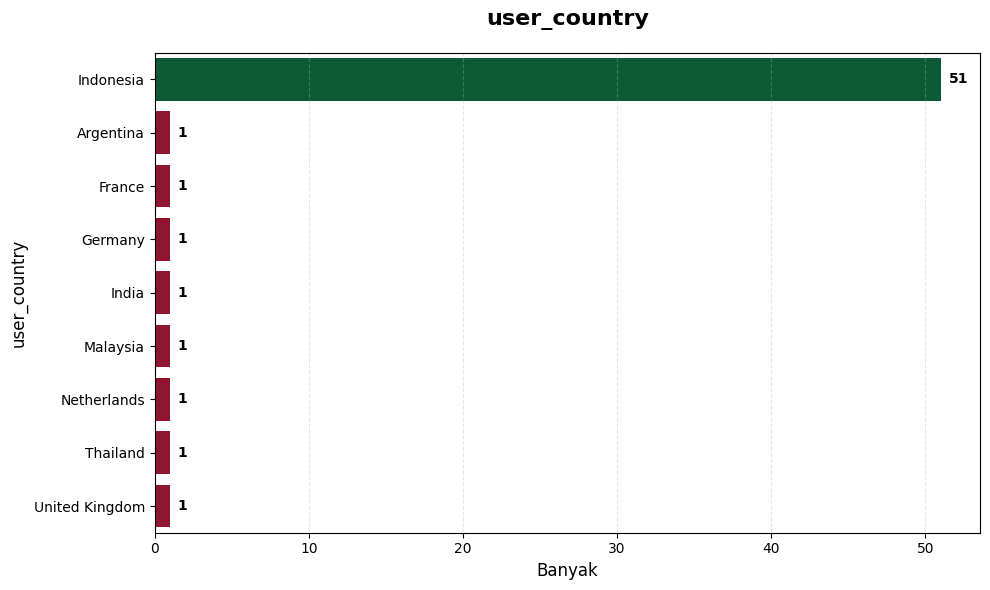

In [20]:
''' 
Membuat sort list dan visualisasi banyak orang tiap user_country
'''
count_gender = df.groupby('user_country').size().reset_index(name='jumlah').sort_values(by='jumlah', ascending=False)
print(count_gender)  
plot_barplot(
    data=count_gender,
    x_col="jumlah",
    y_col="user_country", 
    title="user_country",
    format_number="",
    x_label="Banyak",
    colour_bar_set="1"
)

       room_type  jumlah
0  Standard Room      41
1  Superior Room      18


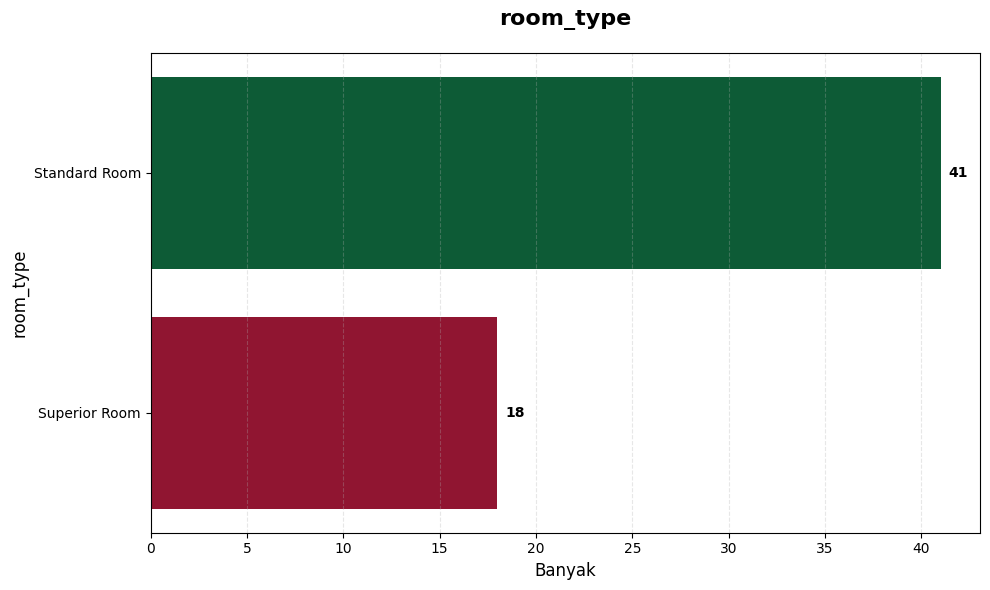

In [21]:
''' 
Membuat sort list dan visualisasi banyak orang tiap room_view
'''
count_gender = df.groupby('room_type').size().reset_index(name='jumlah').sort_values(by='jumlah', ascending=False)
print(count_gender)  
plot_barplot(
    data=count_gender,
    x_col="jumlah",
    y_col="room_type", 
    title="room_type",
    format_number="",
    x_label="Banyak",
    colour_bar_set="1"
)

   stay_duration_days  jumlah
0                   1      46
1                   2      11
2                   3       2


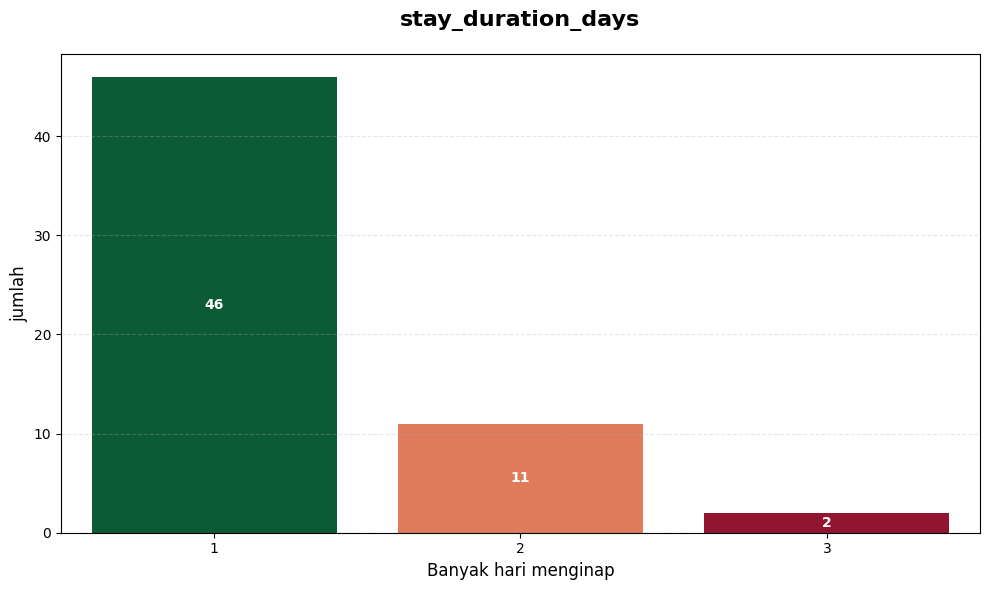

In [22]:
''' 
Membuat sort list dan visualisasi banyak orang tiap stay_duration_days
'''
count_gender = df.groupby('stay_duration_days').size().reset_index(name='jumlah').sort_values(by='jumlah', ascending=False)
print(count_gender)  
plot_barplot(
    data=count_gender,
    x_col="stay_duration_days",
    y_col="jumlah", 
    title="stay_duration_days",
    format_number="",
    x_label="Banyak hari menginap",
    colour_bar_set="1"
)

In [23]:
def plot_multivariate_barplot(df, x_col, hue_col, title="", x_label="", y_label="Jumlah", top_n_hue=5, palette="viridis"):
    """
    Fungsi template Grouped Bar Chart + Garis Tren (FIXED ALIGNMENT).
    """
    
    # --- 1. DATA PREPARATION ---
    data_grouped = df.groupby([x_col, hue_col]).size().reset_index(name='counts')

    # --- 2. FILTER TOP N ---
    top_categories = df[hue_col].value_counts().nlargest(top_n_hue).index.tolist()
    data_filtered = data_grouped[data_grouped[hue_col].isin(top_categories)].copy() # Gunakan .copy() agar aman
    
    # [PENTING] Urutkan berdasarkan Tahun agar garis tidak zig-zag
    data_filtered = data_filtered.sort_values(by=x_col)
    
    # [PENTING] Ubah Tahun menjadi String agar dianggap KATEGORI (bukan angka 0-2000)
    data_filtered[x_col] = data_filtered[x_col].astype(str)

    # --- 3. PRINT TABEL ---
    print("\n" + "="*60)
    print(f"📊 DATA TABEL: {title}")
    print(f"(Hanya menampilkan Top {top_n_hue} kategori '{hue_col}')")
    print("="*60)
    
    try:
        table_view = data_filtered.pivot(index=x_col, columns=hue_col, values='counts').fillna(0).astype(int)
        print(table_view)
    except Exception as e:
        print(f"Gagal membuat tabel pivot: {e}")

    print("-" * 60 + "\n")

    # --- 4. VISUALISASI ---
    plt.figure(figsize=(12, 6))
    
    # LAYER 1: BAR PLOT
    sns.barplot(
        data=data_filtered,
        x=x_col,
        y='counts',
        hue=hue_col,
        palette=palette,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.5 # Transparan agar garis terlihat jelas
    )

    # LAYER 2: POINT PLOT (Pengganti Lineplot)
    # Pointplot otomatis mensejajarkan titik tepat di tengah batang kategori
    sns.pointplot(
        data=data_filtered,
        x=x_col,
        y='counts',
        hue=hue_col,
        palette=palette,
        markers="o",      # Titik bulat
        linestyles="-",   # Garis sambung
        scale=0.7,        # Ukuran titik
        errorbar=None     # Matikan error bar
    )

    # Kosmetik Grafik
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(x_label if x_label else x_col, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    
    # Perbaiki Legend (Hapus duplikat karena ada 2 plot)
    handles, labels = plt.gca().get_legend_handles_labels()
    # Ambil setengah pertama saja (milik barplot)
    plt.legend(handles[:len(top_categories)], labels[:len(top_categories)], title=hue_col, title_fontsize='11', fontsize='10')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=0) 
    plt.tight_layout()
    plt.show()


📊 DATA TABEL: Tren Durasi Menginap per Tahun
(Hanya menampilkan Top 4 kategori 'stay_duration_days')
stay_duration_days   1  2  3
year                        
2022.0              13  0  1
2023.0              10  4  1
2024.0               7  2  0
2025.0               5  0  0
2026.0               3  0  0
------------------------------------------------------------



/tmp/ipykernel_10415/606699496.py:50: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


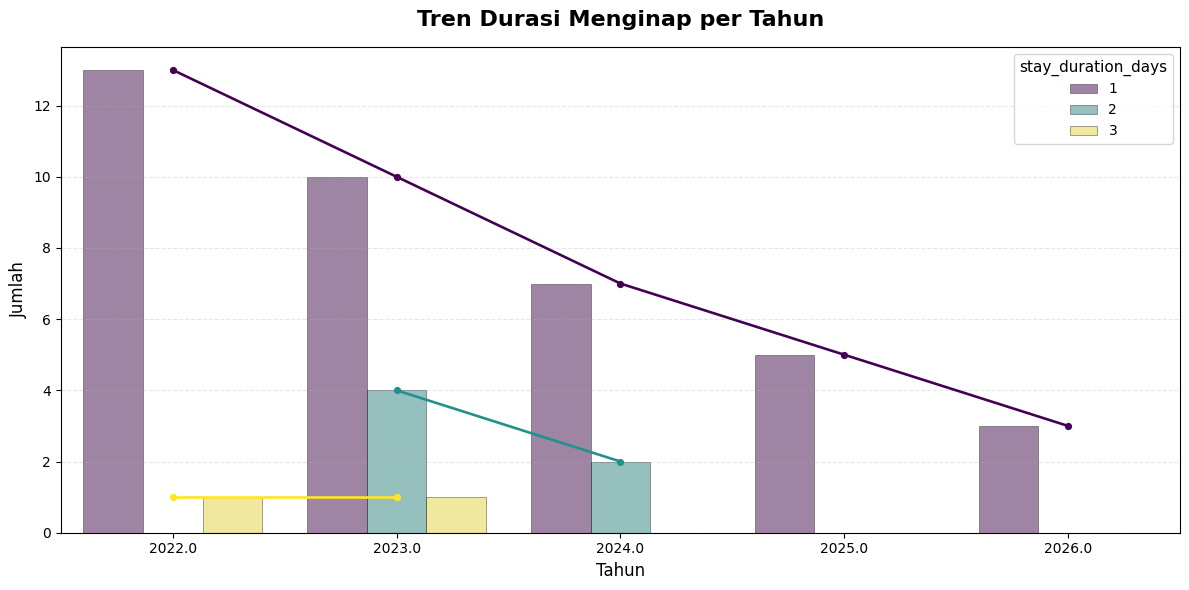

In [24]:
plot_multivariate_barplot(
    df=df,
    x_col="year",
    hue_col="stay_duration_days", # Ganti dengan nama kolom hasil regex tadi
    title="Tren Durasi Menginap per Tahun",
    x_label="Tahun",
    top_n_hue=4 # Hanya ambil 4 durasi terpopuler (misal 1, 2, 3, 4 malam)
)


📊 DATA TABEL: Tren segmen market negara per Tahun
(Hanya menampilkan Top 4 kategori 'user_country')
user_country  India  Indonesia  Malaysia  United Kingdom
year                                                    
2022.0            0         13         1               0
2023.0            0         10         0               1
2024.0            1          8         0               0
2025.0            0          4         0               0
2026.0            0          3         0               0
------------------------------------------------------------



/tmp/ipykernel_10415/606699496.py:50: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


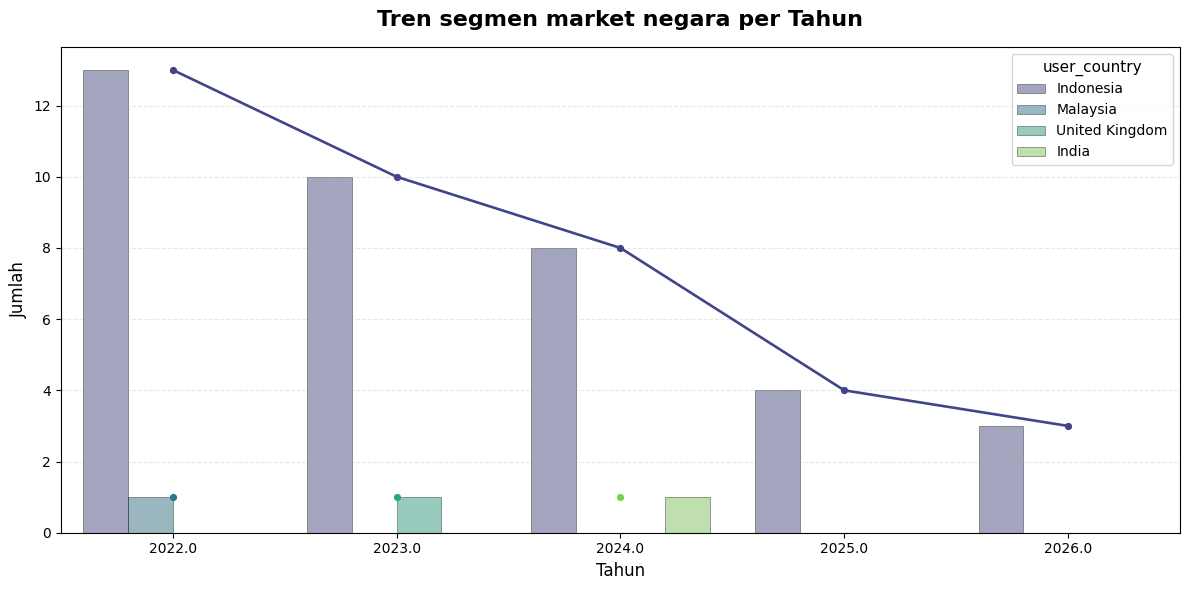

In [25]:
plot_multivariate_barplot(
    df=df,
    x_col="year",
    hue_col="user_country", # Ganti dengan nama kolom hasil regex tadi
    title="Tren segmen market negara per Tahun",
    x_label="Tahun",
    top_n_hue=4 # Hanya ambil 4 durasi terpopuler (misal 1, 2, 3, 4 malam)
)

In [26]:
df

,reviewer_name,user_country,room_type,stay_duration_days,rating,review_text,review_date,year
0,Krisma,Indonesia,Standard Room,1,10.0,"The place is clean and nice, the staff is frie...",NaT,NaN
1,Putrilia,Indonesia,Superior Room,1,10.0,"Nice concept of staying, very clean, not so no...",2026-01-31,2026.0
2,Sagung,Indonesia,Superior Room,2,10.0,Stayed for 2 days here on New Year's Eve. Ever...,NaT,NaN
3,Indrayani,Indonesia,Superior Room,1,10.0,"A unique, clean, and comfortable hotel where w...",NaT,NaN
4,Budi,Indonesia,Superior Room,2,9.2,"The staff service is very good, the cleanlines...",NaT,NaN
5,Evi,Indonesia,Standard Room,1,10.0,"This place is really close to Bali Farm House,...",NaT,NaN
6,Jeni,Indonesia,Standard Room,2,10.0,"Comfortable place, all staff are friendly and ...",NaT,NaN
7,Michael,Indonesia,Standard Room,2,9.6,"This place is nice, but maybe it just needs to...",NaT,NaN
8,Putu,Indonesia,Standard Room,2,9.2,"Initially, I was scrolling through Agoda looki...",NaT,NaN
9,Adi,Indonesia,Superior Room,1,6.8,"The interior has quite a few issues, such as a...",NaT,NaN


       room_type    rating
0  Standard Room  9.082927
1  Superior Room  9.200000


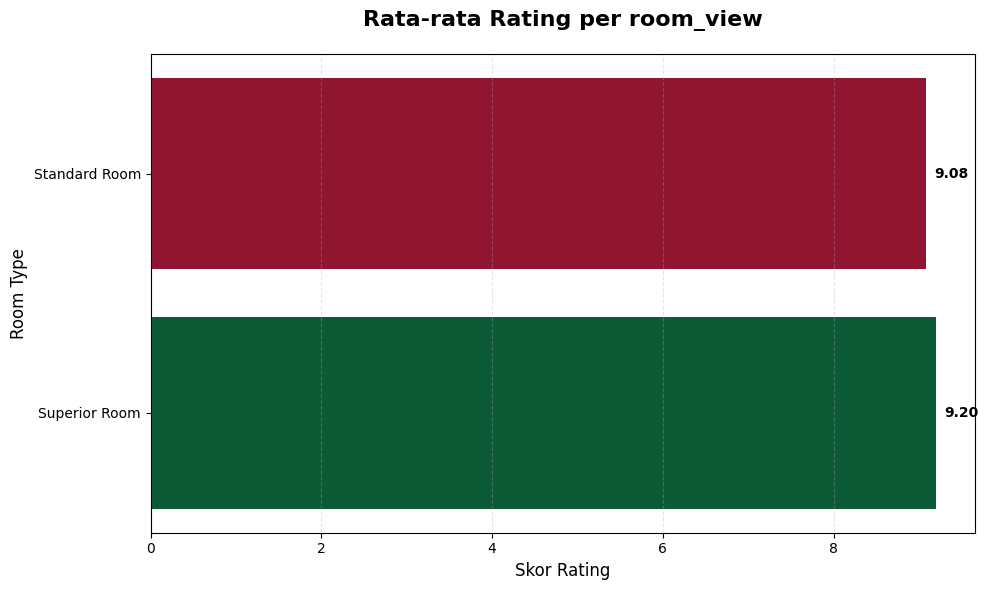

In [27]:
# Reset index agar 'Year' kembali menjadi kolom
rating_room_year = df.groupby('room_type')['rating'].mean().reset_index()

rating_room_year = rating_room_year[rating_room_year!= 0]

# Opsional: Urutkan tahun biar rapi
rating_room_year = rating_room_year.sort_values('rating')

print(rating_room_year)

# --- CARA PENGGUNAAN ---
plot_barplot(
    data=rating_room_year , 
    x_col="rating", 
    y_col="room_type", 
    title="Rata-rata Rating per room_view", 
    x_label="Skor Rating",
    y_label="Room Type",
    colour_bar_set="1" # Gunakan 3 (Biru) untuk data tahunan agar netral
)

In [28]:
filtered_df = df[df['review_text'] != 0].copy()
# Baru di-grouping
dislike_by_room_view = filtered_df.groupby('room_type')['review_text'].apply(list)

# --- CARA MENGAKSES HASILNYA (Sama seperti kodemu) ---
print("=== Statistik Dislike per Kamar ===")
for room_type, comments in dislike_by_room_view.items():
    print(f"Pada {room_type}: Ditemukan {len(comments)} komentar.")
    print(f"{comments}") 
    print("-" * 30)

=== Statistik Dislike per Kamar ===
Pada Standard Room: Ditemukan 41 komentar.
['The place is clean and nice, the staff is friendly and helpful even though they are alone but quite efficient, it would be better if there were more staff, bringing a 1-year-old toddler is safe because the cold is pleasant, the location is close to the lake, it takes a 5-minute walk to get there, and around there are many beautiful vegetable and fruit gardens, thank you for the complimentary drinks, very helpful 🙏🏻', "This place is really close to Bali Farm House, very clean, delicious food and quite affordable, you can get free hot drinks at the reception like chocolate, tea, and coffee, friendly staff, they also have a hairdryer, it's very complete.", 'Comfortable place, all staff are friendly and very helpful. \n\nThe owner is very helpful and responsive in answering questions. \n\nHighly recommended to come back here again.', "This place is nice, but maybe it just needs to be more viral, and the Wi-Fi 

In [29]:
df

,reviewer_name,user_country,room_type,stay_duration_days,rating,review_text,review_date,year
0,Krisma,Indonesia,Standard Room,1,10.0,"The place is clean and nice, the staff is frie...",NaT,NaN
1,Putrilia,Indonesia,Superior Room,1,10.0,"Nice concept of staying, very clean, not so no...",2026-01-31,2026.0
2,Sagung,Indonesia,Superior Room,2,10.0,Stayed for 2 days here on New Year's Eve. Ever...,NaT,NaN
3,Indrayani,Indonesia,Superior Room,1,10.0,"A unique, clean, and comfortable hotel where w...",NaT,NaN
4,Budi,Indonesia,Superior Room,2,9.2,"The staff service is very good, the cleanlines...",NaT,NaN
5,Evi,Indonesia,Standard Room,1,10.0,"This place is really close to Bali Farm House,...",NaT,NaN
6,Jeni,Indonesia,Standard Room,2,10.0,"Comfortable place, all staff are friendly and ...",NaT,NaN
7,Michael,Indonesia,Standard Room,2,9.6,"This place is nice, but maybe it just needs to...",NaT,NaN
8,Putu,Indonesia,Standard Room,2,9.2,"Initially, I was scrolling through Agoda looki...",NaT,NaN
9,Adi,Indonesia,Superior Room,1,6.8,"The interior has quite a few issues, such as a...",NaT,NaN


/tmp/ipykernel_10415/3179651340.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.set_index(date_col).resample('M').size()


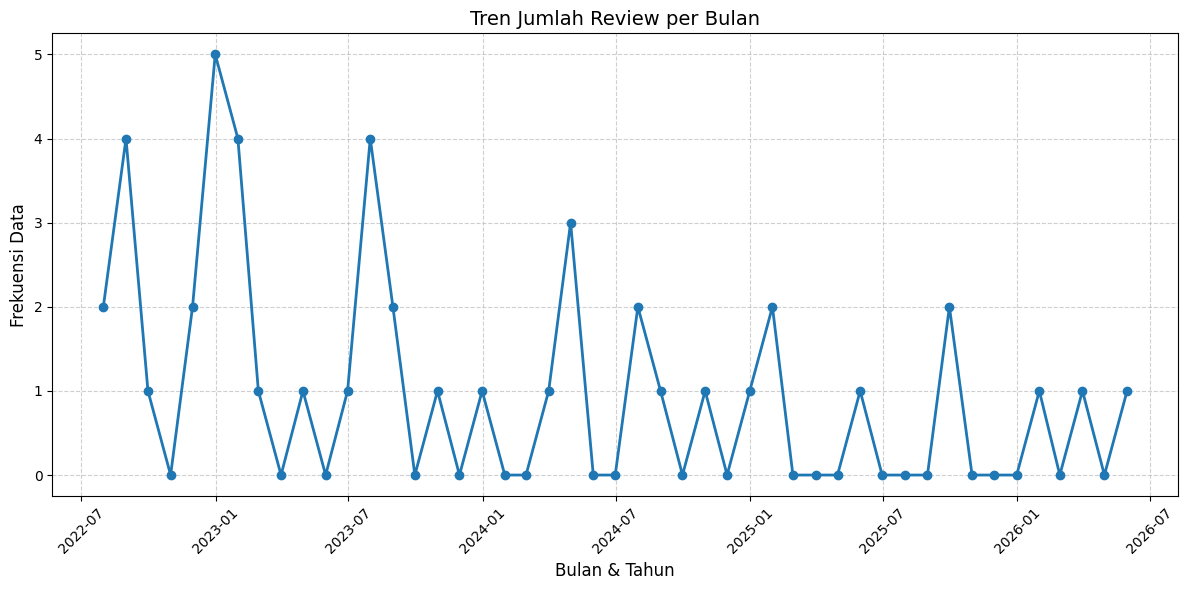

review_date
2022-12-31    5
2023-07-31    4
2022-08-31    4
2023-01-31    4
2024-04-30    3
2024-07-31    2
2023-08-31    2
2022-07-31    2
2025-09-30    2
2022-11-30    2
2025-01-31    2
2025-05-31    1
2024-03-31    1
2024-12-31    1
2024-10-31    1
2024-08-31    1
2026-01-31    1
2026-03-31    1
2026-05-31    1
2023-12-31    1
2022-09-30    1
2023-10-31    1
2023-06-30    1
2023-04-30    1
2023-02-28    1
2024-02-29    0
2025-06-30    0
2026-04-30    0
2026-02-28    0
2022-10-31    0
2025-12-31    0
2025-11-30    0
2025-10-31    0
2025-08-31    0
2025-07-31    0
2025-04-30    0
2023-03-31    0
2024-01-31    0
2025-03-31    0
2025-02-28    0
2023-05-31    0
2024-11-30    0
2024-09-30    0
2023-09-30    0
2023-11-30    0
2024-05-31    0
2024-06-30    0
dtype: int64

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pastikan kolom tanggal dikenali sebagai datetime
# Ganti 'published_at_date' dengan 'review_post_date' jika Anda sudah merename kolomnya
date_col = 'review_date' 
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# 2. Resample data per Bulan (M) dan hitung jumlahnya (.size())
# Kita set tanggal sebagai index dulu agar bisa di-resample
monthly_counts = df.set_index(date_col).resample('M').size()

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linestyle='-', color='#1f77b4', linewidth=2)

# Mempercantik tampilan
plt.title(f'Tren Jumlah Review per Bulan', fontsize=14)
plt.xlabel('Bulan & Tahun', fontsize=12)
plt.ylabel('Frekuensi Data', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Tampilkan
plt.show()
monthly_counts.sort_values(ascending=False)

--- Total Data Per Bulan (Akumulasi Semua Tahun) ---
review_date
July         8
January      7
August       7
December     7
April        4
September    3
March        2
May          2
October      2
November     2
February     1
June         1
Name: count, dtype: int64


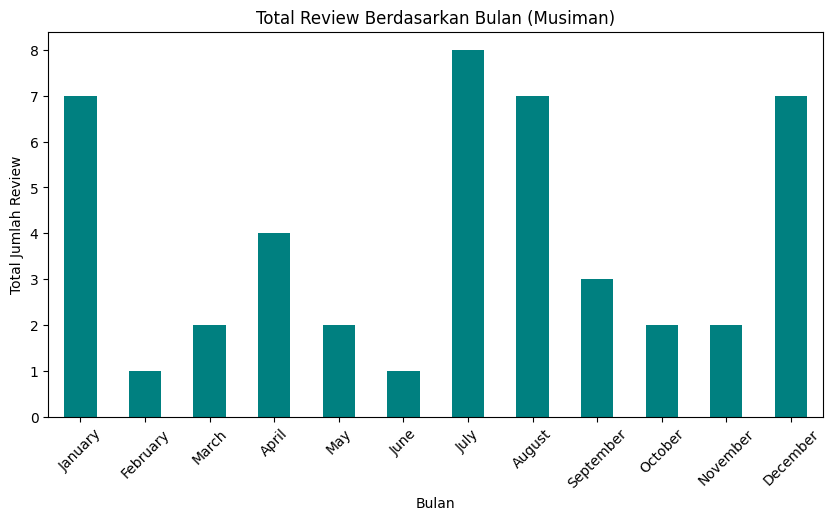

In [31]:
import pandas as pd

# 1. Pastikan kolom target sudah format datetime
col_name = 'review_date'  # Sesuaikan nama kolom tanggal Anda
df[col_name] = pd.to_datetime(df[col_name], errors='coerce')

# 2. Urutan bulan yang benar (agar tidak terurut abjad April duluan)
bulan_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# 3. Ambil nama bulan dan hitung
# dt.month_name() mengambil nama bulan (Jan, Feb, dst) mengabaikan tahun
monthly_counts = df[col_name].dt.month_name().value_counts()

# 4. Urutkan hasil sesuai kalender (bukan jumlah terbanyak)
monthly_counts = monthly_counts.reindex(bulan_order, fill_value=0)

# 5. Tampilkan Hasil
print("--- Total Data Per Bulan (Akumulasi Semua Tahun) ---")
print(monthly_counts.sort_values(ascending=False))

# --- Opsional: Tampilkan dalam Grafik Batang ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
monthly_counts.plot(kind='bar', color='teal')
plt.title('Total Review Berdasarkan Bulan (Musiman)')
plt.xlabel('Bulan')
plt.ylabel('Total Jumlah Review')
plt.xticks(rotation=45)
plt.show()